## PRCP-1012-GameWinnerPred

### TABLE OF CONTENTS
1. Understanding the Objective
2. Importing Required Libraries
3. Loading the Dataset and EDA
4. Scaling & Feature Engineering
5. Model Development
6. Conclusion and Insights

### 1. Objective
    Building a model to predict the win probability of the PUBG match, based on the given features.

### 2. Importing Necessaary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

pubg = pd.read_csv(r"C:\Users\Admin\Desktop\Data_Science\Internship\Data Sets\Game Winner - PUBG\pubg.csv")
pubg

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.000,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.040,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.000,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.000,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.000,0,0,49.75,2,0,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446961,afff7f652dbc10,d238e426f50de7,18492834ce5635,0,0,0.00,0,0,0,74,...,0,1292.0000,0,0.000,0,0,1019.00,3,1507,0.1786
4446962,f4197cf374e6c0,408cdb5c46b2ac,ee854b837376d9,0,1,44.15,0,0,0,69,...,0,0.0000,0,0.000,0,0,81.70,6,0,0.2935
4446963,e1948b1295c88a,e26ac84bdf7cef,6d0cd12784f1ab,0,0,59.06,0,0,0,66,...,0,0.0000,0,2.184,0,0,788.70,4,0,0.4815
4446964,cc032cdd73b7ac,c2223f35411394,c9c701d0ad758a,0,4,180.40,1,1,2,11,...,2,0.0000,0,0.000,0,0,2748.00,8,0,0.8000


### Exploratory Data Analysis:
Duplicate Check: Verify the dataset for any duplicate entries to prevent redundant data. If duplicates are found, they should be removed to enhance the model’s performance.

Null Value Check: Inspect the dataset for missing values to avoid bias. If null values are present, they should be appropriately imputed or replaced based on the nature of the data.

Data Type Verification: Examine the data types of all features. If any non-numerical features exist, they must be encoded into numerical format before model training.

Statistical Summary: Perform an overall statistical analysis to understand metrics such as mean, median, standard deviation, and maximum values. This helps in effective feature engineering.

Visualization: Create visualizations to analyze features and gain better insights into their relationships.

In [2]:
pubg.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [2]:
pubg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

In [3]:
pubg.duplicated().sum()

np.int64(0)

In [4]:
pubg.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [3]:
pubg = pubg.dropna()
#Upon detecting a single null entry in the dataset, we opted to drop the record rather than impute the missing value.

In [6]:
pubg.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       0
dtype: int64

In [4]:
pubg.columns

Index(['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='object')

In [7]:
pubg.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,...,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06,4.446965e+06
mean,2.338150e-01,1.106908e+00,1.307172e+02,6.578757e-01,2.268196e-01,1.370148e+00,4.759936e+01,5.050062e+02,9.247835e-01,5.439553e-01,...,1.646590e-01,6.061158e+02,3.496092e-03,4.509323e+00,2.386841e-02,7.918209e-03,1.154218e+03,3.660488e+00,6.064603e+02,4.728216e-01
std,5.885731e-01,1.715794e+00,1.707806e+02,1.145743e+00,6.021553e-01,2.679982e+00,2.746293e+01,6.275049e+02,1.558445e+00,7.109721e-01,...,4.721671e-01,1.498344e+03,7.337297e-02,3.050220e+01,1.673935e-01,9.261158e-02,1.183497e+03,2.456543e+00,7.397005e+02,3.074050e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.551000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,0.000000e+00,0.000000e+00,8.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.856000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,0.000000e+00,2.000000e+00,1.860000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.172000e+03,1.000000e+00,1.000000e+00,...,0.000000e+00,1.910000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.976000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,2.200000e+01,3.300000e+01,6.616000e+03,5.300000e+01,6.400000e+01,8.000000e+01,1.010000e+02,2.170000e+03,7.200000e+01,2.000000e+01,...,3.900000e+01,4.071000e+04,1.800000e+01,3.823000e+03,1.200000e+01,5.000000e+00,2.578000e+04,2.360000e+02,2.013000e+03,1.000000e+00


#### Removed features that were unnecessary for the analysis.

In [4]:
pubg = pubg.drop(['Id', 'groupId', 'matchId'],axis=1)
pubg.columns

Index(['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
       'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill',
       'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints',
       'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
       'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
       'winPlacePerc'],
      dtype='object')

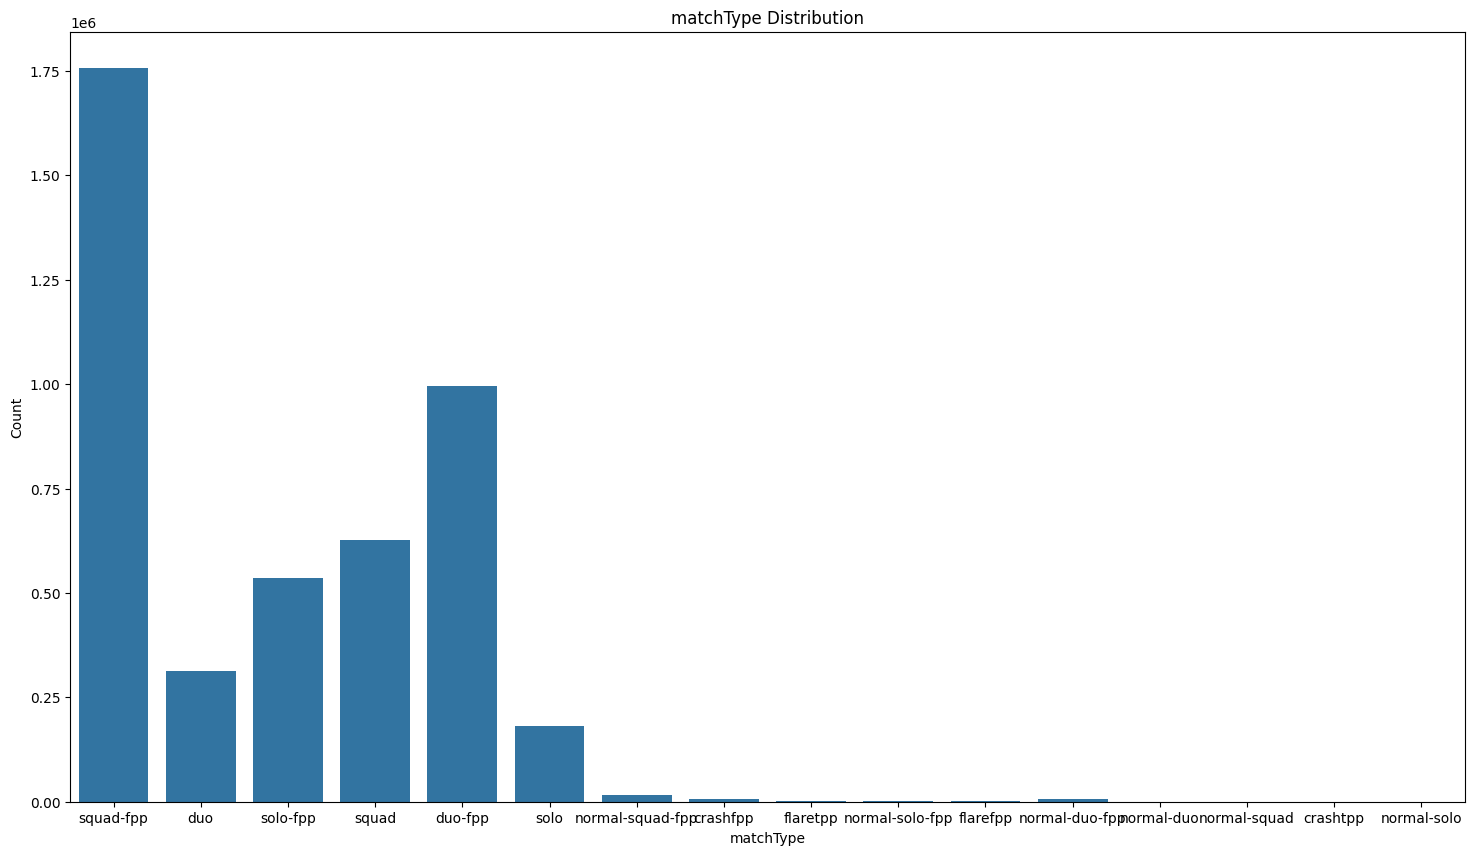

matchType
squad-fpp           0.394918
duo-fpp             0.224128
squad               0.140888
solo-fpp            0.120703
duo                 0.070518
solo                0.040914
normal-squad-fpp    0.003862
crashfpp            0.001414
normal-duo-fpp      0.001234
flaretpp            0.000563
normal-solo-fpp     0.000378
flarefpp            0.000161
normal-squad        0.000116
crashtpp            0.000083
normal-solo         0.000073
normal-duo          0.000045
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(18,10))
sns.countplot(x='matchType', data=pubg)
plt.title("matchType Distribution")
plt.xlabel("matchType")
plt.ylabel("Count")
plt.show()
print(pubg['matchType'].value_counts(normalize=True))

#### Insight
- This Indicates that Squad-Fpp match has Played more than other Games.

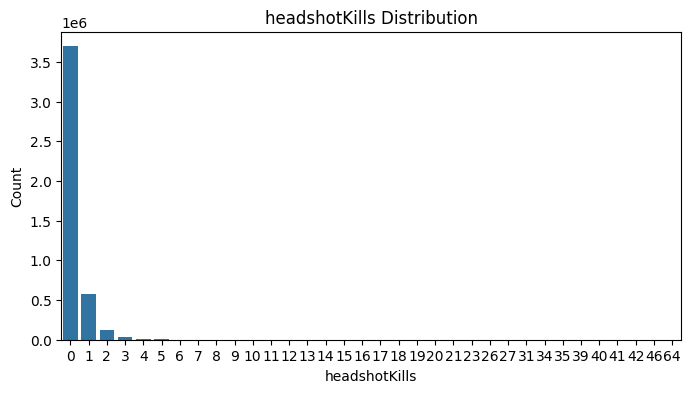

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(x='headshotKills', data=pubg)
plt.title("headshotKills Distribution")
plt.xlabel("headshotKills")
plt.ylabel("Count")
plt.show()

#### Insight
- The headshot distribution indicates that only a small number of kills occurred through headshots.
- When players attempted a headshot, it typically resulted in either a single kill or a missed shot.

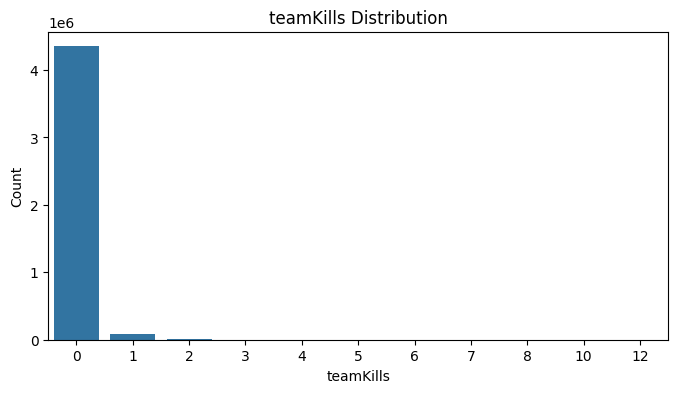

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(x='teamKills', data=pubg)
plt.title("teamKills Distribution")
plt.xlabel("teamKills")
plt.ylabel("Count")
plt.show()

#### Insight
- A very small number of players have 1 or more team kills, indicating that team killing is a rare event in the dataset.

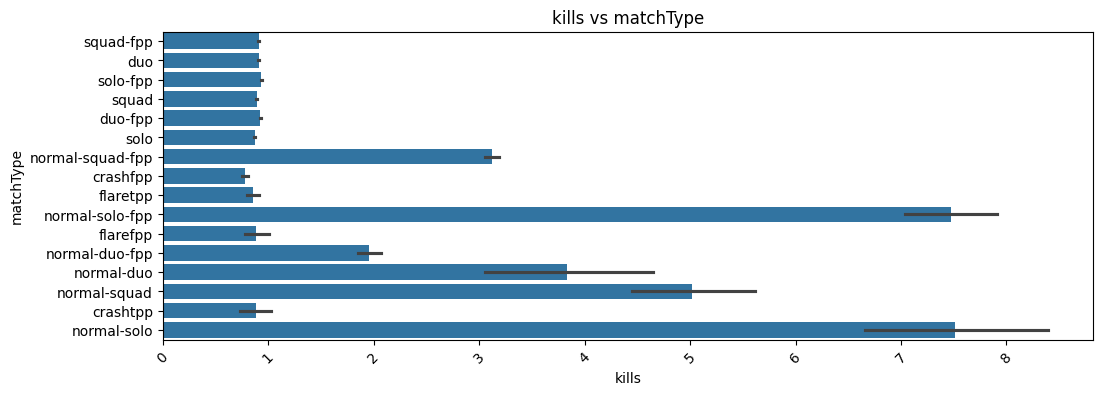

In [8]:
plt.figure(figsize=(12,4))
sns.barplot(x='kills', y='matchType', data=pubg)
plt.title("kills vs matchType")
plt.xticks(rotation=45)
plt.show()

#### Insight
- Normal modes (normal-solo, normal-squad, normal-duo) show the highest kill counts
These modes consistently have higher average kills, especially normal-solo and normal-squad, indicating players tend to engage more aggressively in these match types.
- Event/rare modes (flarefpp, crashtpp, flaretpp) show very low kill counts These modes may involve fewer players, special conditions, or unique rules leading to limited combat.
- Regular non-event TPP modes (solo, duo, squad) fall in the mid-range They show moderate kill numbers, not as high as the normal modes but more than rare modes.
- Normal-solo stands out with the highest kill potential Solo matches naturally require players to fight independently, resulting in more engagements per player.

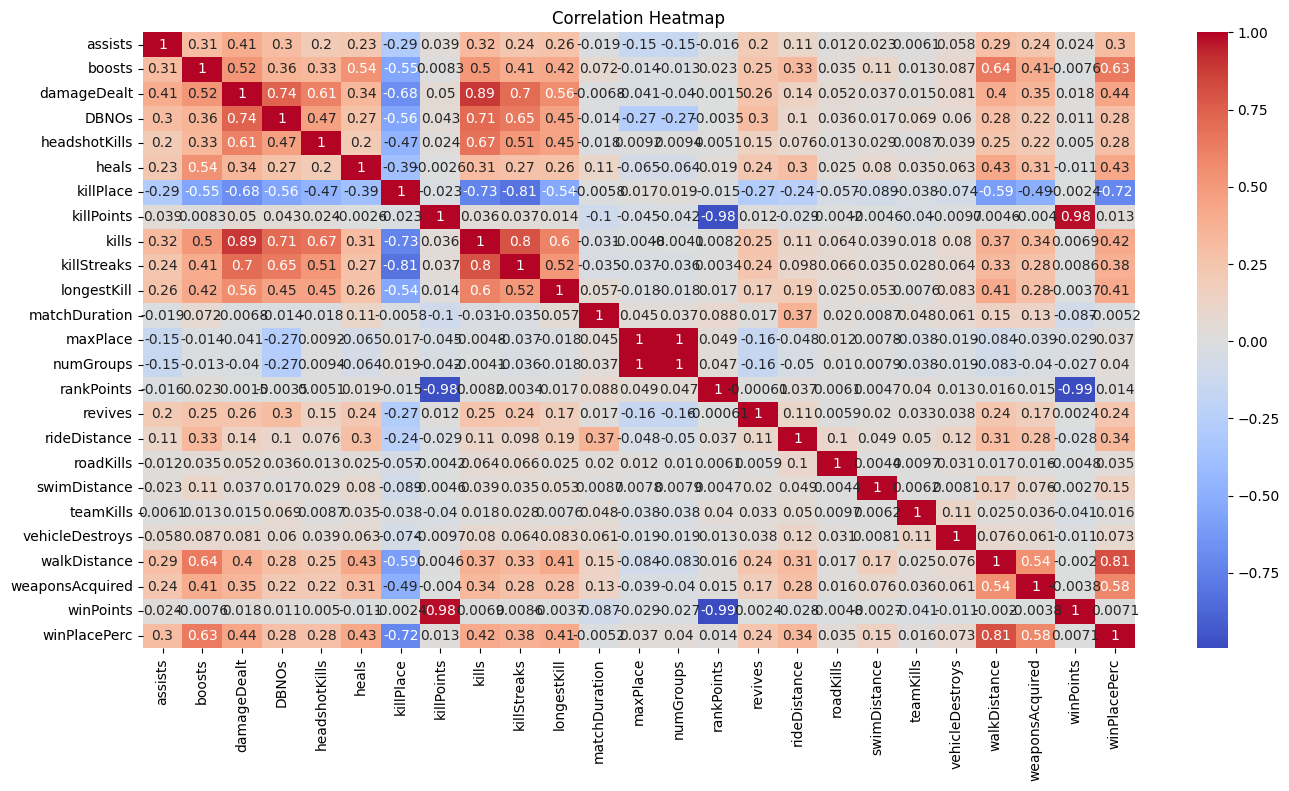

In [10]:
plt.figure(figsize=(16,8))
sns.heatmap(pubg.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Key Insights from Correlation Analysis

- Movement-related features such as walkDistance (0.81), rideDistance (0.59), and swimDistance (0.44) show the strongest positive correlation with winPlacePerc.
This indicates that mobility plays a crucial role in increasing a player’s survival and final ranking.

- Boosts (0.63) and heals (0.51) also correlate positively with winning, meaning players who frequently use healing and boosting items tend to survive longer.

- killPlace has a strong negative correlation (–0.72) with winPlacePerc. Since lower killPlace means a higher kill ranking, this suggests that players with better kill performance generally place higher.

- Highly correlated feature groups were identified, such as:

  kills & killPoints (0.93)

  winPoints & winPlacePerc (0.71)

These indicate multicollinearity within the dataset.

- Some combat-related features (e.g., DBNOs, headshotKills) show weak correlation with match placement, suggesting that winning PUBG is more about       survival, movement, and strategy than raw combat skills.

- matchDuration has minimal impact, showing that the length of the match does not necessarily influence winning.

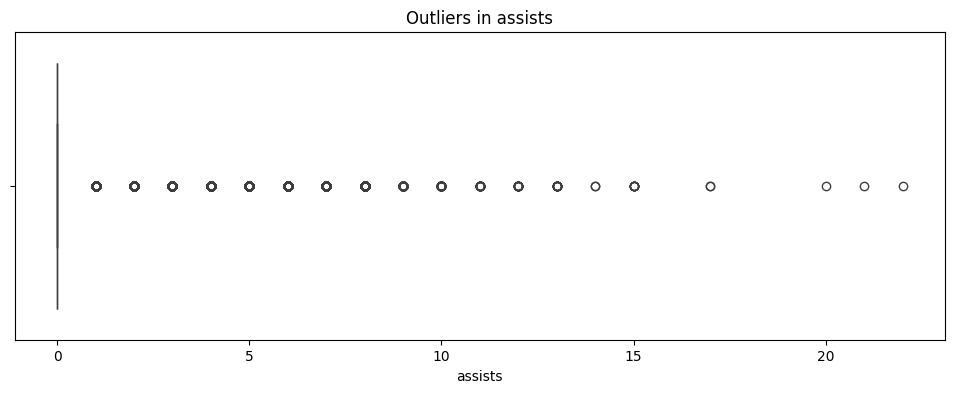

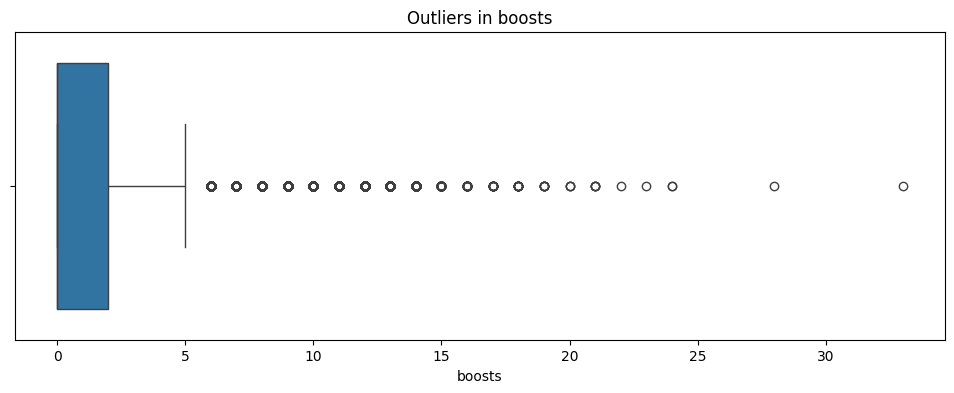

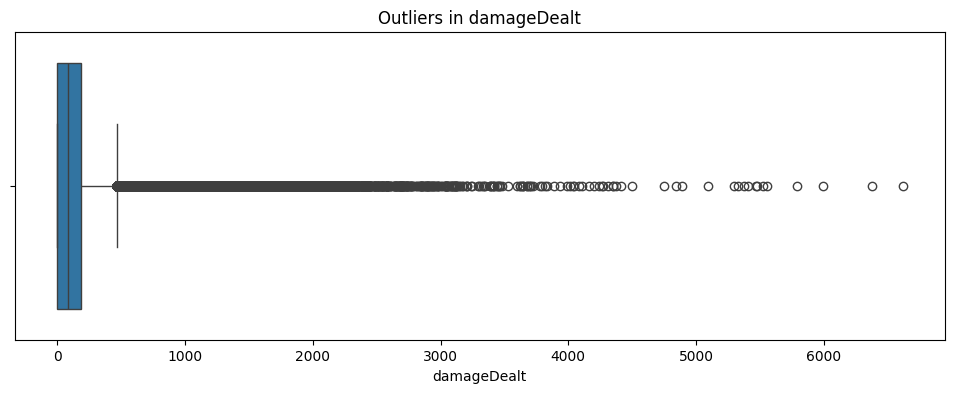

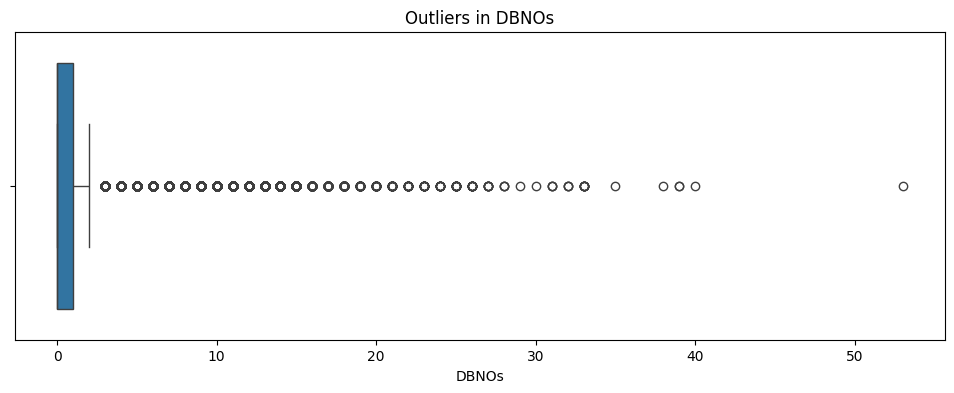

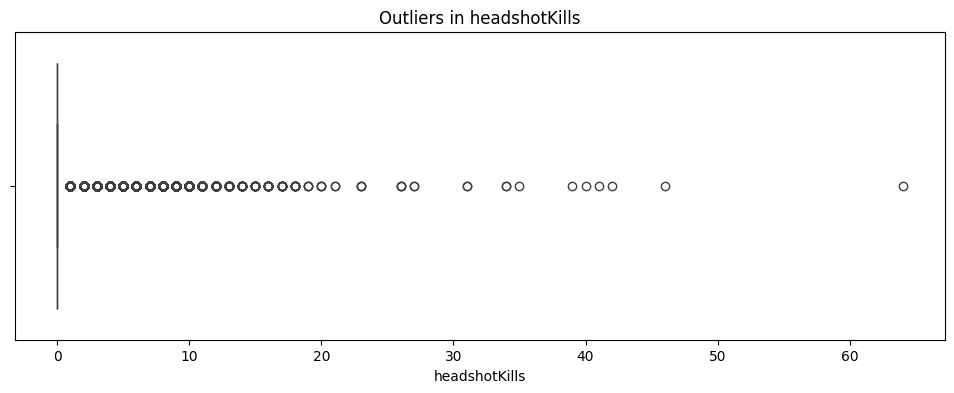

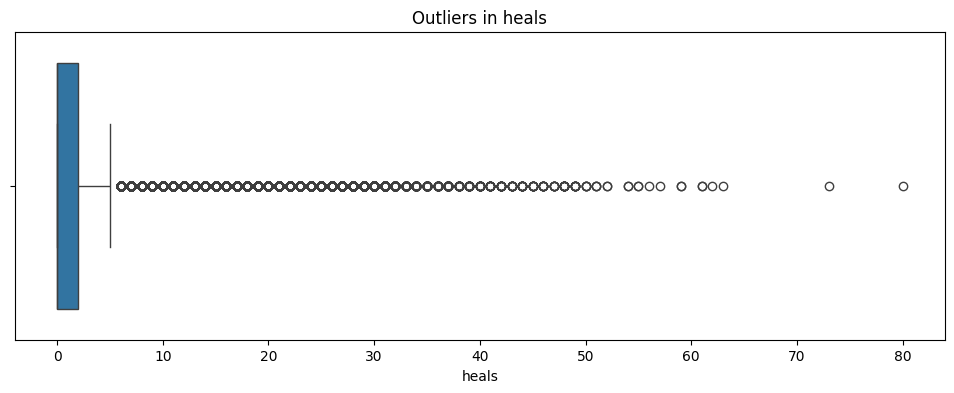

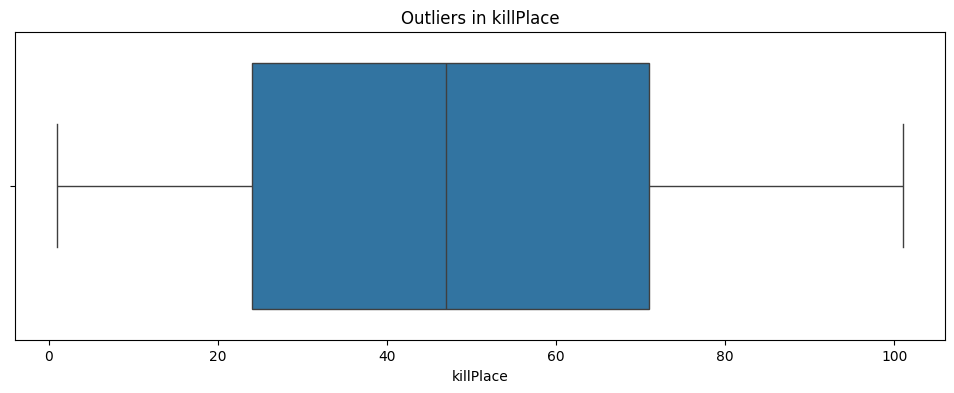

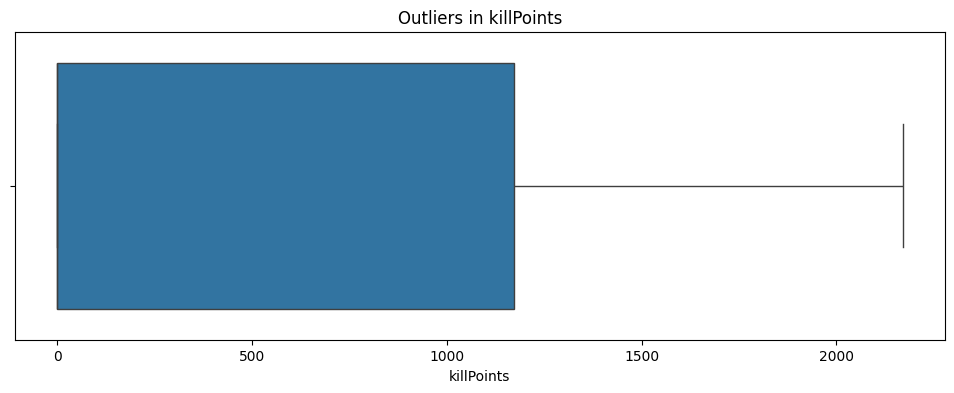

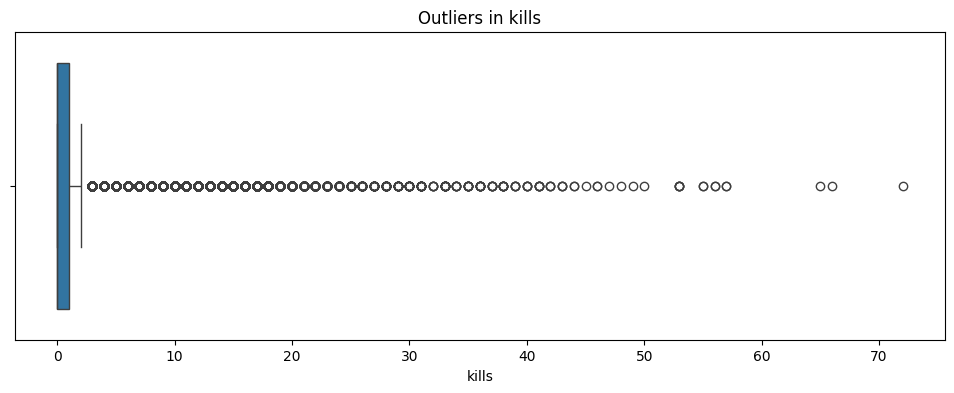

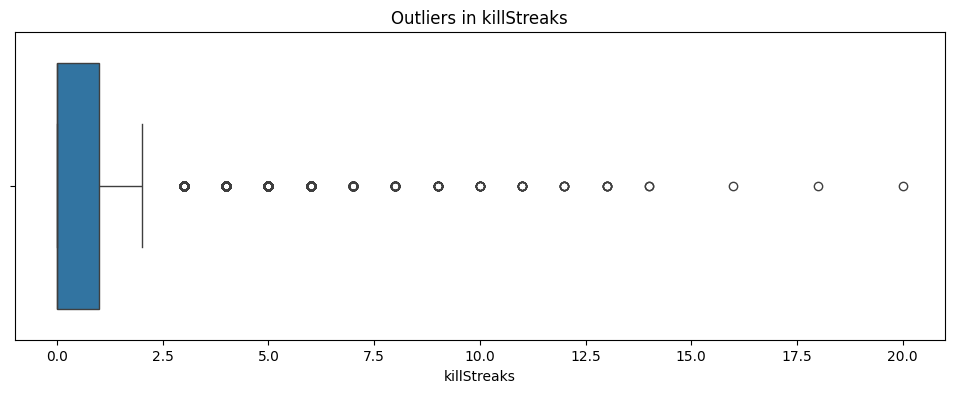

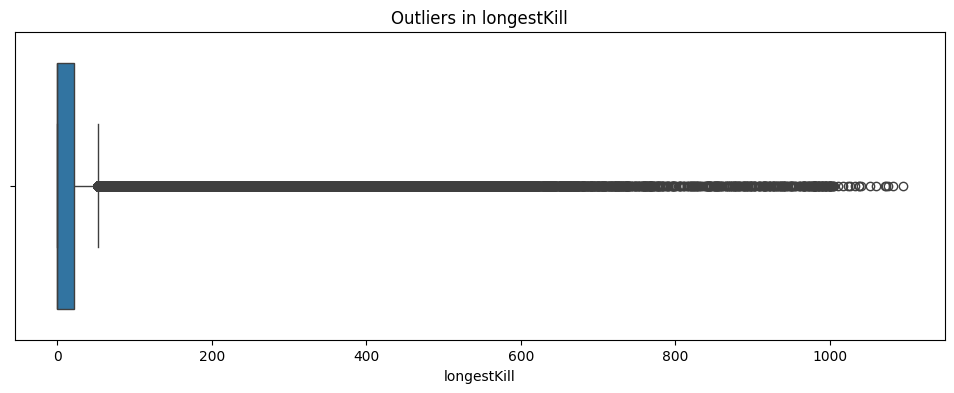

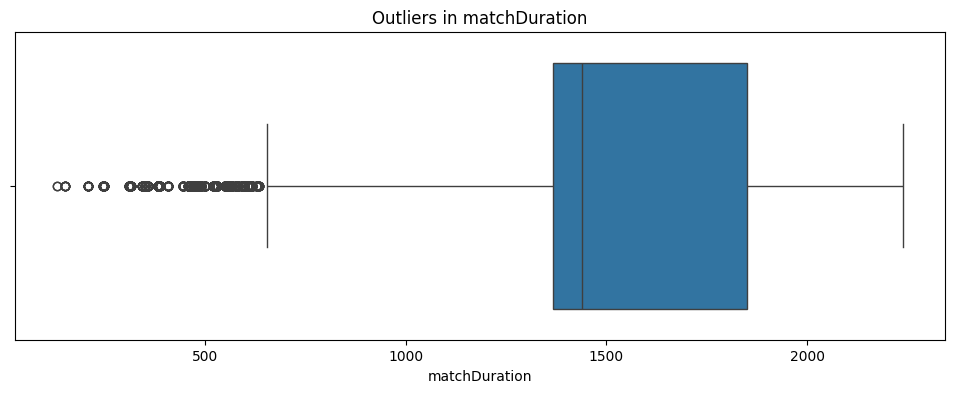

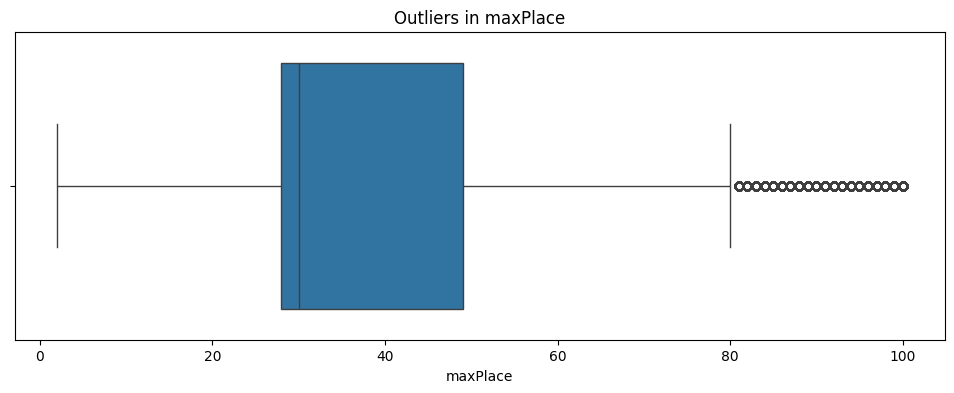

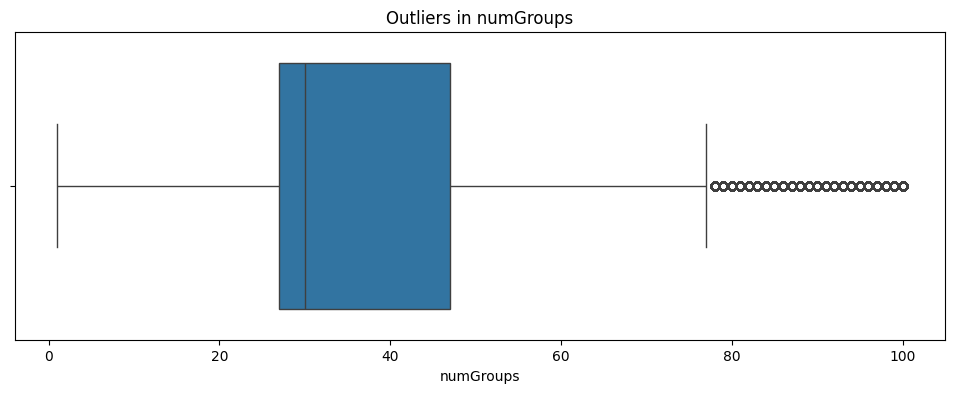

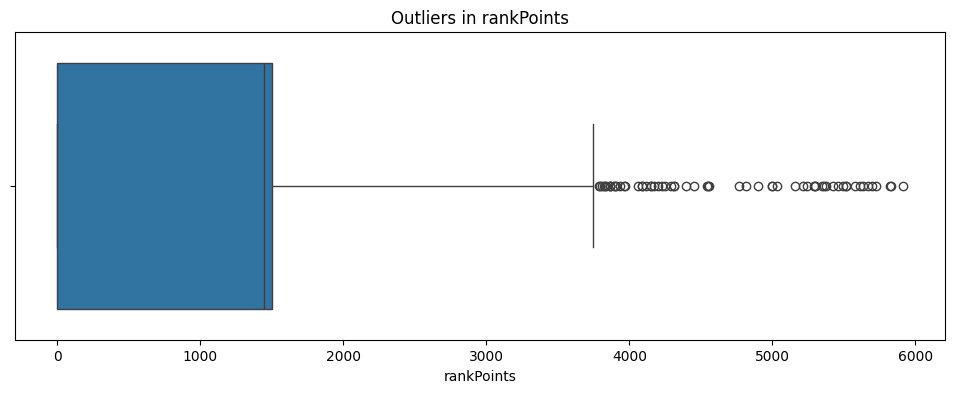

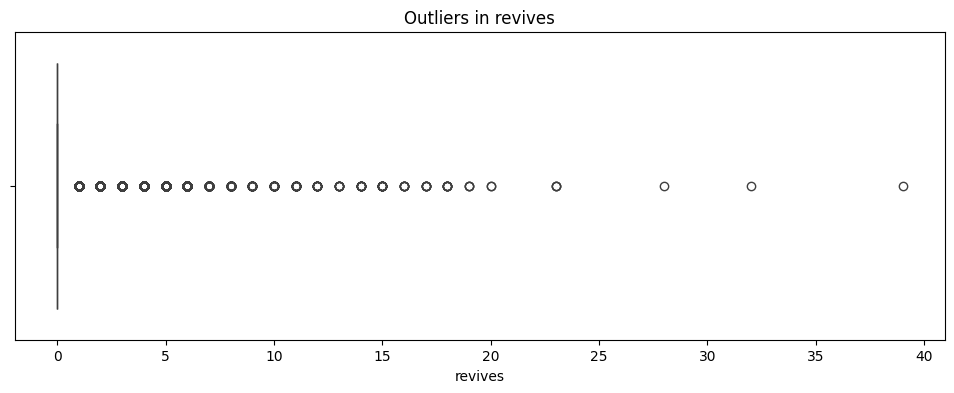

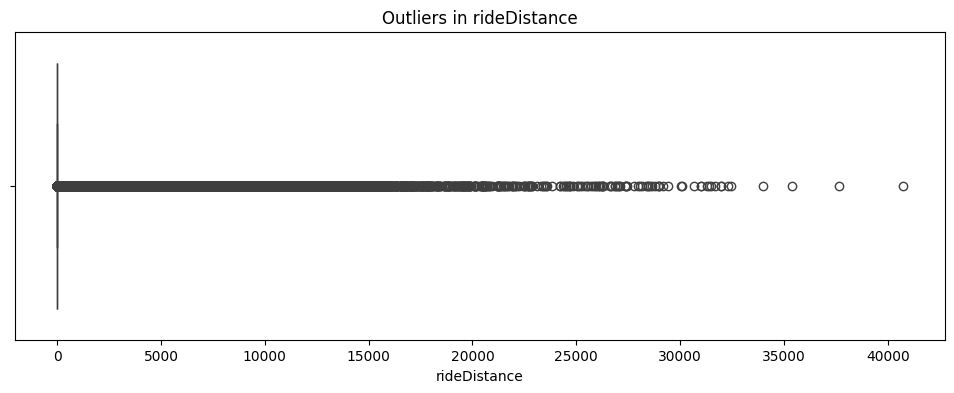

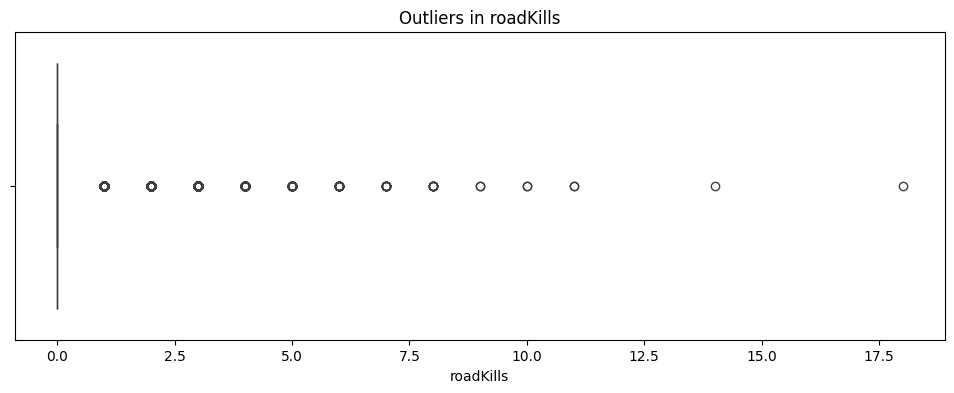

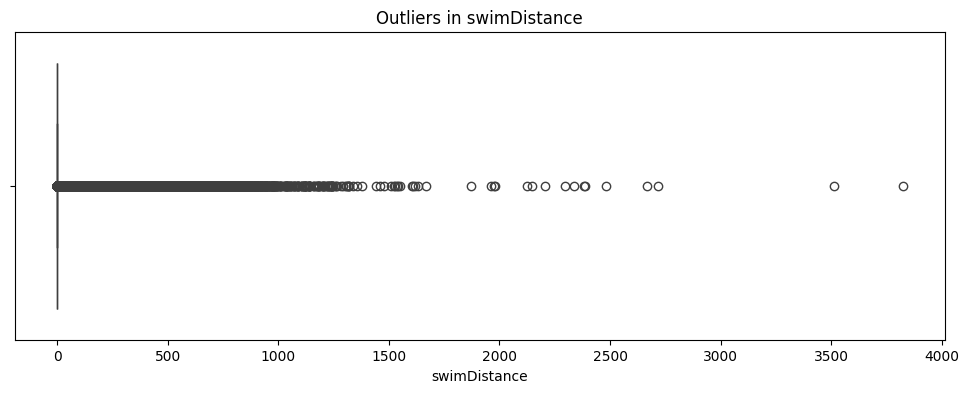

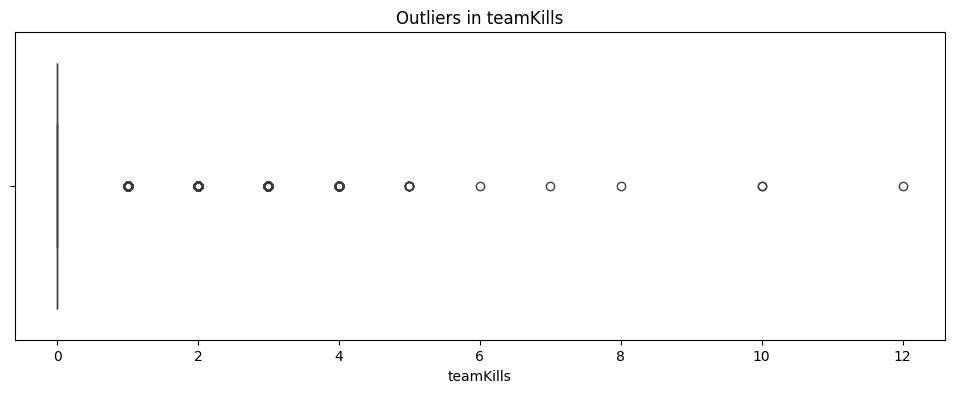

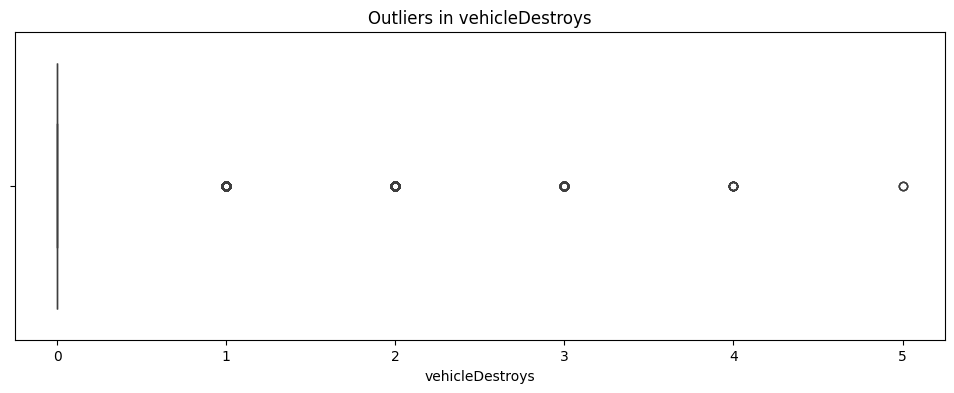

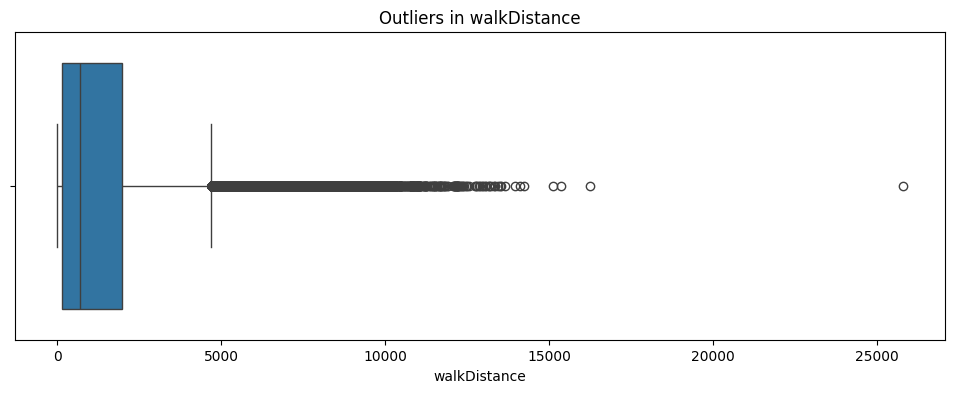

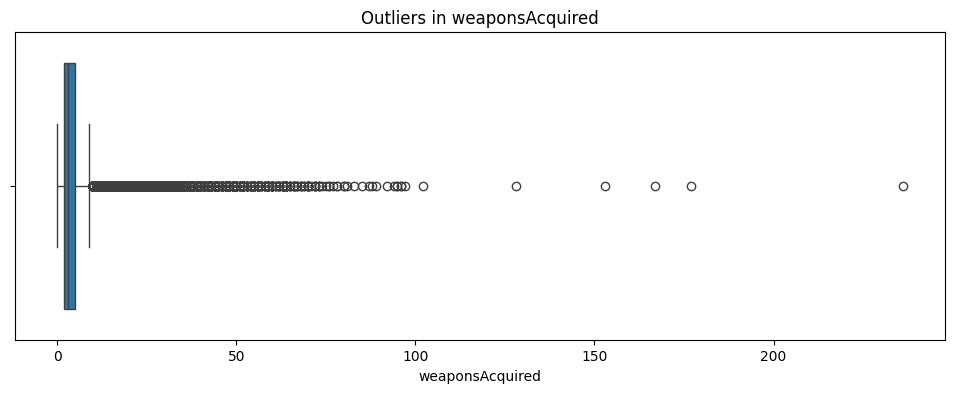

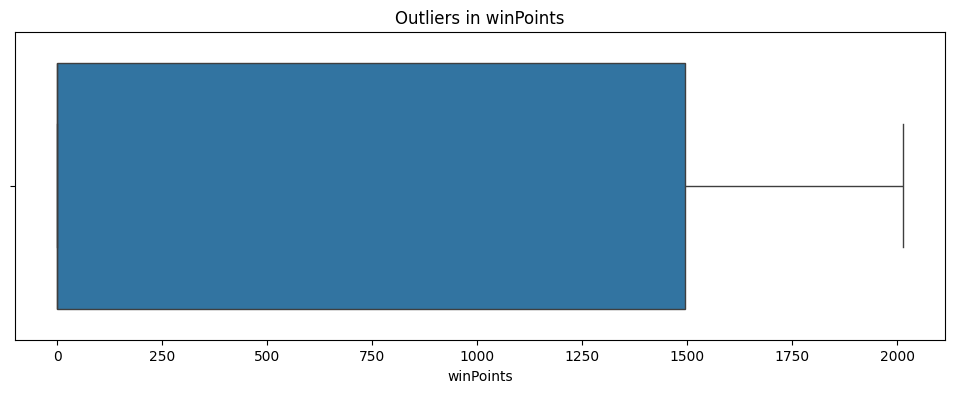

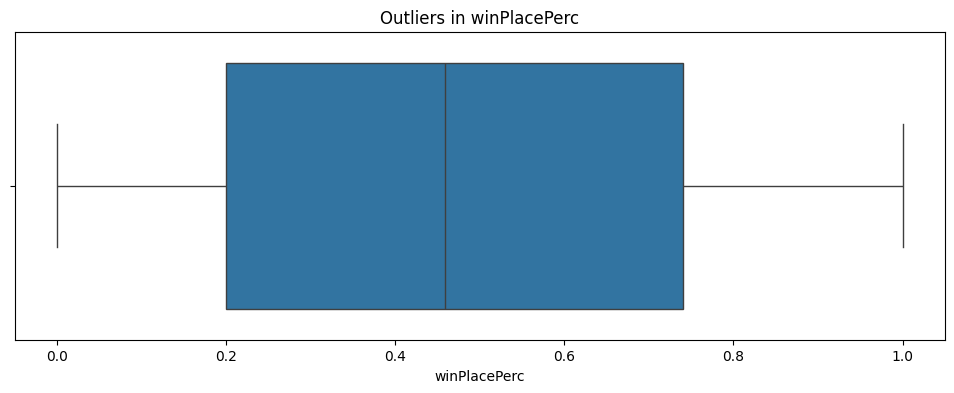

In [12]:
num_cols = pubg.drop("winPlacePerc", axis=1)
num_cols = pubg.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=pubg[col])
    plt.title(f"Outliers in {col}")
    plt.show()

- Several features show outliers, they represent valid game situations. These values are important for modeling real PUBG behavior, so no outlier removal is applied.
- Therefore, these outliers are intentionally retained, as removing them would distort the true distribution of on-field behavior and reduce the model’s ability to generalize to real gameplay scenarios.

In [9]:
pubg["matchType"].unique()

array(['squad-fpp', 'duo', 'solo-fpp', 'squad', 'duo-fpp', 'solo',
       'normal-squad-fpp', 'crashfpp', 'flaretpp', 'normal-solo-fpp',
       'flarefpp', 'normal-duo-fpp', 'normal-duo', 'normal-squad',
       'crashtpp', 'normal-solo'], dtype=object)

#### 4. Scaling and Feature Engineering

##### Encoding
- Categorical features were encoded into numerical values for model compatibility

In [5]:
pubg = pd.get_dummies(pubg, columns= ["matchType"], drop_first=False)
pubg.shape

(4446965, 41)

##### Separate Input and Output

In [6]:
x=pubg.drop("winPlacePerc", axis=1)
y=pubg["winPlacePerc"]

##### Scaling
- Data was scaled to a uniform range to ensure greater stability during model training

In [7]:
scaler = StandardScaler()
x=scaler.fit_transform(x)

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train", y_train.shape)
print("y_test",y_test.shape)

x_train (3112875, 40)
x_test (1334090, 40)
y_train (3112875,)
y_test (1334090,)


### 5. Model Development
Testing with Multiple Models for Better Prediction

#### Linear Regression

In [9]:
lr=LinearRegression()
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred_lr = lr.predict(x_test)

In [23]:
y_predc_lr = lr.predict(x_train)

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(x_train, y_train)
rf_preds = rf.predict(x_test)
rf_predis = rf.predict(x_train)

#### Why Random Forest Was Not Used for Final Modeling

During experimentation, the Random Forest model caused a memory allocation error:

“MemoryError: could not allocate 268435456 bytes”

This occurred because Random Forest requires storing multiple deep decision trees in memory.
With a dataset of 4.4 million rows and 41 features, the memory requirement becomes very high.
Since the algorithm uses bagging and creates many independent trees, RAM consumption increases rapidly.

Due to this limitation, Random Forest was not suitable for this dataset on the available hardware.

#### XGB

- Due to the large dataset, RandomSearchCV and GridSearchCV were intentionally omitted to prevent performance overhead. Instead, the model parameters were finalized after multiple tuning experiments to select the best-performing configuration

In [29]:
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=300,       
    learning_rate=0.1,      
    max_depth=10,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
)


model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:

y_pred_xgb = model.predict(x_test)
y_predc_xgb = model.predict(x_train)

#### LightGBM

In [15]:

pubg_sample = pubg.sample(frac=0.03, random_state=42)

X_sample = pubg_sample.drop('winPlacePerc', axis=1)
y_sample = pubg_sample['winPlacePerc']

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

#### Using RandomizedSearchCV to understand better parameters

In [16]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


lgbm = LGBMRegressor(random_state=42)


param_dist = {
    'num_leaves': [31, 50, 70, 100],
    'max_depth': [-1, 10, 15, 20],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700, 1000],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}


random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,                  
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)


random_search.fit(X_train_s, y_train_s)

print("Best parameters:", random_search.best_params_)
best_lgbm = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2793
[LightGBM] [Info] Number of data points in the train set: 106727, number of used features: 35
[LightGBM] [Info] Start training from score 0.470593
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [17]:
final_lgbm = LGBMRegressor(**random_search.best_params_, random_state=42)
final_lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.672861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2862
[LightGBM] [Info] Number of data points in the train set: 3112875, number of used features: 40
[LightGBM] [Info] Start training from score 0.472924


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,10
,learning_rate,0.05
,n_estimators,700
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred_lgbm = final_lgbm.predict(x_test)
y_predc_lgbm = final_lgbm.predict(x_train)

In [26]:
def evaluate_model(name, y_train, y_train_pred, y_test, y_test_pred):
    return {
        "Model": name,
        
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),

        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),

        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }


In [34]:
results_list = []

# Linear Regression
results_list.append(
    evaluate_model(
        "Linear Regression",
        y_train, y_predc_lr,
        y_test, y_pred_lr
    )
)

# XGBoost
results_list.append(
    evaluate_model(
        "XGBoost",
        y_train, y_predc_xgb,
        y_test, y_pred_xgb
    )
)

# LightGBM
results_list.append(
    evaluate_model(
        "LightGBM",
        y_train, y_predc_lgbm,
        y_test, y_pred_lgbm
    )
)


results_df = pd.DataFrame(results_list)
results_df


,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.839754,0.839549,0.089899,0.089902,0.123081,0.123079
1,XGBoost,0.941746,0.935137,0.053478,0.055659,0.074210,0.078255
2,LightGBM,0.934779,0.933481,0.056393,0.056662,0.078522,0.079247


#### Why Big Data Technologies Were Not Used

1. Although the dataset contains 4.4 million rows, it still fits within the capacity of modern local systems and can be efficiently processed using optimized libraries such as Pandas and LightGBM.
2. In this project, the dataset was large but manageable, and LightGBM's histogram-based algorithm handled it efficiently without requiring distributed processing. Therefore, using Big Data frameworks would have introduced unnecessary complexity without providing meaningful performance benefits.

### 6.Conclusion

1. The goal of this project was to develop a predictive model for PUBG’s winPlacePerc using player performance statistics. After conducting comprehensive data preprocessing, exploratory data analysis, feature engineering, and testing multiple machine learning models, the results clearly highlight the performance differences across algorithms.

2. From the correlation analysis, it was observed that mobility and survival-related features—such as walkDistance, rideDistance, heals, boosts, and weaponsAcquired—have the strongest positive influence on final placement. This confirms that strategic movement and sustained survival contribute more to match success than pure combat metrics like headshotKills or DBNOs.

3. Multiple machine learning models were evaluated and compared using R², MAE, and RMSE on both training and test data:

- Linear Regression served as the baseline, achieving an R² of 0.839, indicating it could capture basic trends but failed to model the nonlinear complexity of PUBG gameplay.

- Random Forest was attempted, but the dataset size (4.4M rows × 41 features) caused a MemoryError, demonstrating that memory-heavy bagging algorithms are not suitable for this dataset under the available system resources.

- XGBoost delivered the strongest performance with a test R² of 0.935, MAE of 0.0556, and RMSE of 0.0782, showing excellent accuracy and generalization capabilities.

- LightGBM, known for its efficiency on large datasets, also performed exceptionally well with a test R² of 0.933, MAE of 0.0566, and RMSE of 0.0792, very close to XGBoost while training significantly faster.

4. Based on the results, XGBoost and LightGBM stand out as the most effective models, with XGBoost achieving the highest accuracy overall. However, LightGBM demonstrated comparable performance with superior training efficiency and lower resource usage, making it an excellent choice for large-scale applications.
5. Since XGBoost shows a good balance across these metrics, it can be considered the most suitable model for this dataset.